In [1]:
#import libraries...
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the cleaned CSV...
df = pd.read_csv('water_potability_cleaned.csv')

In [4]:
# Split features and target
X = df.drop('Potability', axis=1)   # Features
y = df['Potability']                # Target

In [5]:
# Training - Test Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Logistic Regression model...
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

In [10]:
# Evaluation...
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.5015243902439024
Precision: 0.36990595611285265
Recall: 0.48360655737704916
F1 Score: 0.4191829484902309
ROC-AUC: 0.4978712398535731


In [11]:
# Random Forest model...
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [12]:
# Evaluation...
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.6676829268292683
Precision: 0.6015625
Recall: 0.3155737704918033
F1 Score: 0.41397849462365593
ROC-AUC: 0.5958936813624065


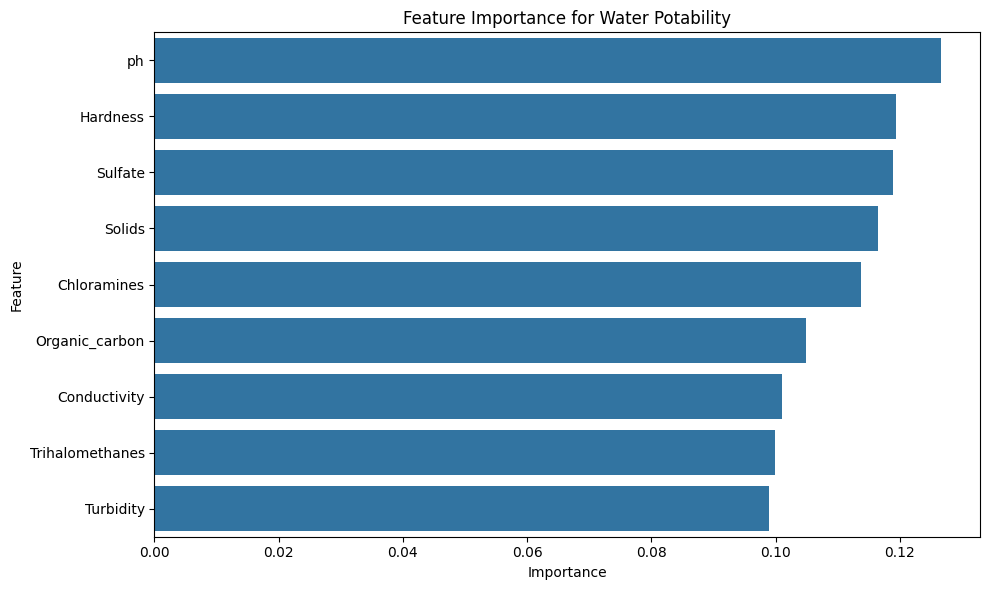

In [13]:
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy plotting
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Feature Importance for Water Potability')
plt.tight_layout()
plt.show()

In [14]:
import pickle

# Save the Random Forest model
with open('water_quality_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

# Save the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)